# **Task 5: Decision Trees and Random Forests**
- ## **Objective: Learn tree-based models for classification & regression.** 
- ## **Tools:  Scikit-learn, Graphviz**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("heart.csv")  # Ensure heart.csv is in the same directory

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **1.Train a Decision Tree Classifier and visualize the tree.**

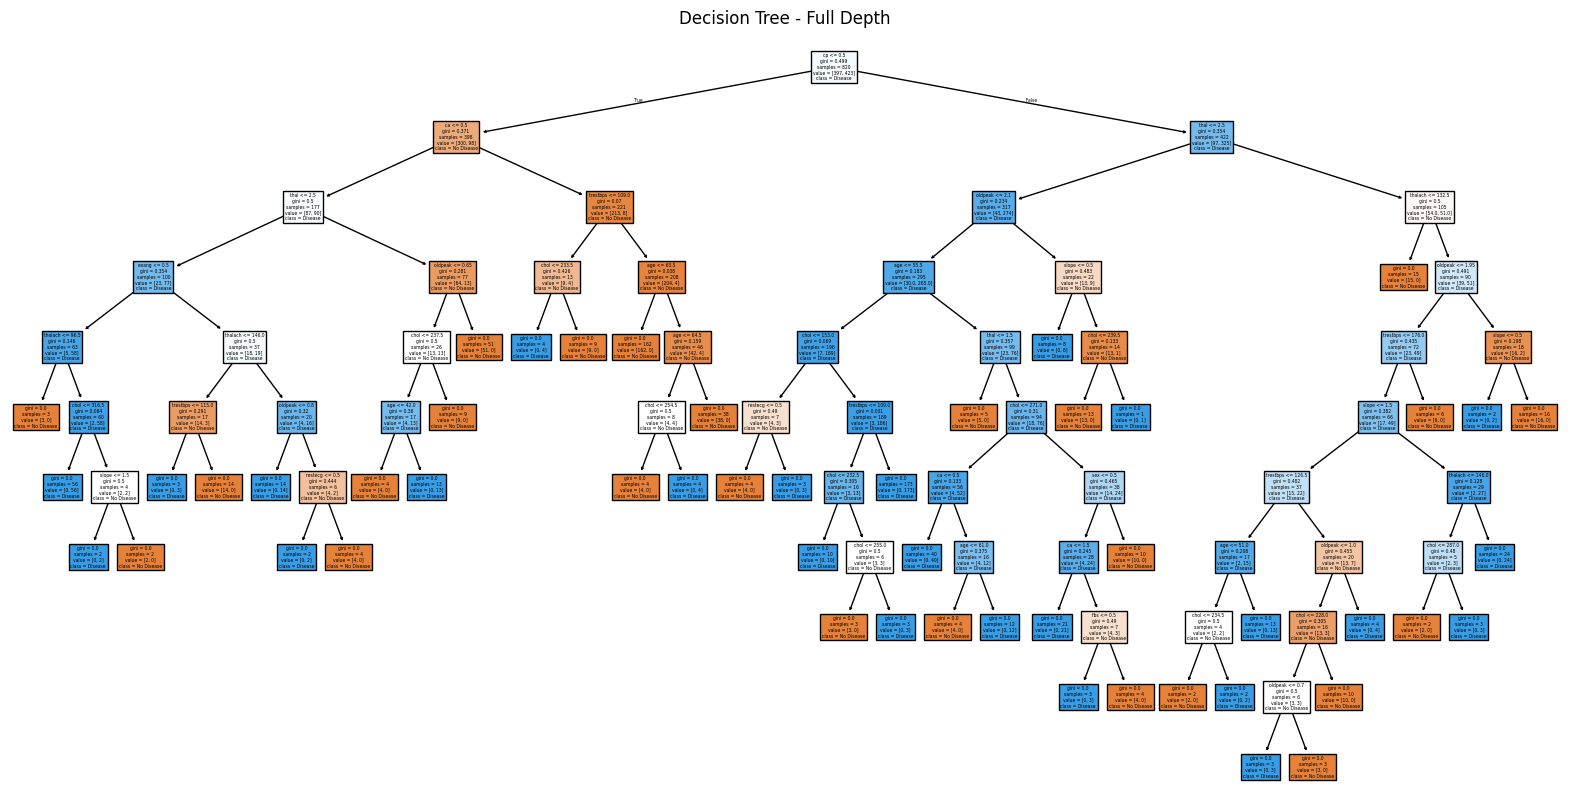

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.title("Decision Tree - Full Depth")
plt.show()

### **2.Analyze overfitting and control tree depth.**

In [4]:
# Train Decision Tree with max depth
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)

# Evaluate
print("Decision Tree with max_depth=4")
print("Training Accuracy:", dt_pruned.score(X_train, y_train))
print("Testing Accuracy :", dt_pruned.score(X_test, y_test))

Decision Tree with max_depth=4
Training Accuracy: 0.8829268292682927
Testing Accuracy : 0.8


### **3.Train a Random Forest and compare accuracy.**

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
print("Random Forest")
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy :", rf_model.score(X_test, y_test))

Random Forest
Training Accuracy: 1.0
Testing Accuracy : 0.9853658536585366


### **4.Interpret feature importances.**

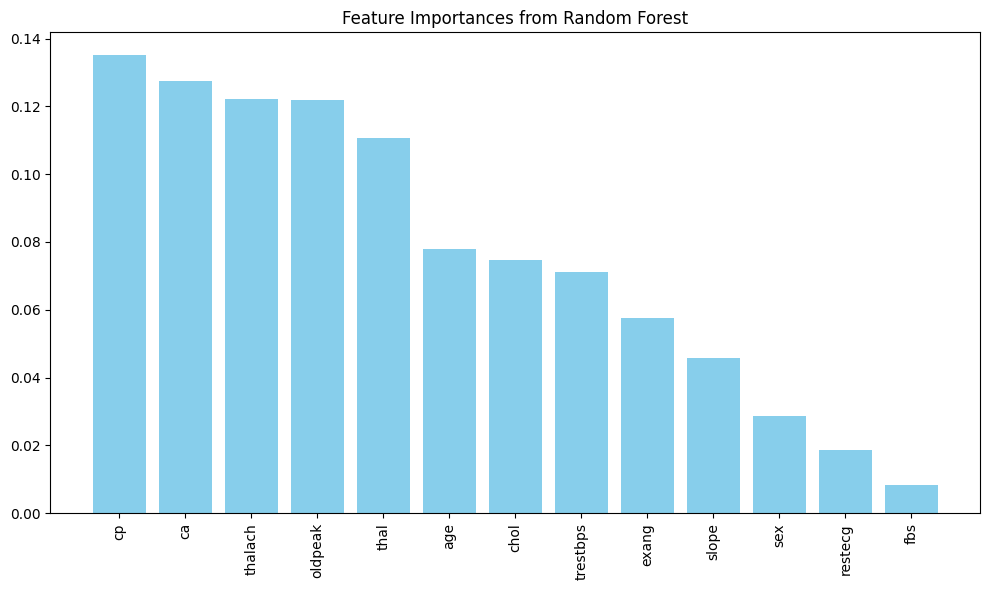

In [6]:
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances from Random Forest")
plt.bar(range(X.shape[1]), importances[indices], color="skyblue", align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

### **5.Evaluate using cross-validation.**

In [7]:
from sklearn.model_selection import cross_val_score

# Cross-validation scores
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9970731707317073
